<a href="https://colab.research.google.com/github/Lucidousme/ecommerce-revenue-kpi-analysis/blob/main/E_commerce_Revenue_%26_KPI_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import (
    precision_recall_curve, classification_report, roc_auc_score,
    confusion_matrix, fbeta_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import shap
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


Data Cleaning and Preprocessing

In [2]:
df = pd.read_excel("Online Retail.xlsx", engine="openpyxl")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#Check for missing Data
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [4]:
# Calculate percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [5]:
# Drop tiny missing Description values
df = df.dropna(subset=['Description'])

# Remove returns and invalid prices (VERY important for retail data)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Calculate Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']


The dataset contains 0.26% missing values in the description column.Since the value is less significant, I dropped the missing values in the column. On the other hand, it also contains 24.9% missing CustomerID values, likely
representing anonymous transactions. Instead of removing these records entirely, they were retained for revenue and sales analysis while a filtered dataset was created for customer-level metrics to preserve analytical accuracy.

In [6]:
missing_revenue = df[df['CustomerID'].isna()]['Revenue'].sum()
total_revenue = df['Revenue'].sum()

print((missing_revenue / total_revenue) * 100)

16.45569092026202


Also, in other to confirm whether to completely drop the missing "customer ID", I checked the reveune contribution of these missing values and it as 16% of the entire revenue. Therefore, it is not a good choice dropping these values as it can undermine some part of the analysis.

In [7]:
# Full dataset (for revenue & product KPIs)
df_full = df.copy()

# Customer analytics dataset (drop missing IDs)
df_customers = df.dropna(subset=['CustomerID']).copy()

What I did here was to create to dataset. There is a full dataset where I did not drop missing values in the 'Customer ID' column. This is to help ensure I am able to completely calculate revenue and other product KPIs. On the other hand, I created another dataset where I dropped missing IDs in the 'Customer ID' column, this will help ensure I can properly calculate customer behavior.

In [8]:
df_full.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
# check missing data in the full dataset
df_full.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132220
Country,0
Revenue,0


In [10]:
#check missing data in the 'customer analytics' dataset
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
df_customers.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


Calculate Core KPIs for both Dataset

In [12]:
#Caculate Revenue for Both Datasets
df_full['Revenue'] = df_full['Quantity'] * df_full['UnitPrice']
df_customers['Revenue'] = df_customers['Quantity'] * df_customers['UnitPrice']

In [13]:
#Total Revenue (Full Dataset)
total_revenue = df_full['Revenue'].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 10666684.54


In [14]:
#Total Order
total_orders = df_full['InvoiceNo'].nunique()
print("Total Orders:", total_orders)

Total Orders: 19960


In [15]:
#Total Unique Customers
total_customers = df_customers['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 4338


I used the "Customer Dataset" here because missing IDs in the full dataset would inflate/invalid this metric.

In [16]:
#Average Order Value (AOV)
order_revenue = df_full.groupby('InvoiceNo')['Revenue'].sum()
AOV = order_revenue.mean()

print("Average Order Value (AOV):", round(AOV, 2))

Average Order Value (AOV): 534.4


This calculates the average value per transaction. With this, I am able to understand average amount that customers spend on the products.

In [17]:
#Monthly Revenue Trend
df_full['InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])
df_full['YearMonth'] = df_full['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_full.groupby('YearMonth')['Revenue'].sum()
print(monthly_revenue)

YearMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: Revenue, dtype: float64


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='YearMonth'>

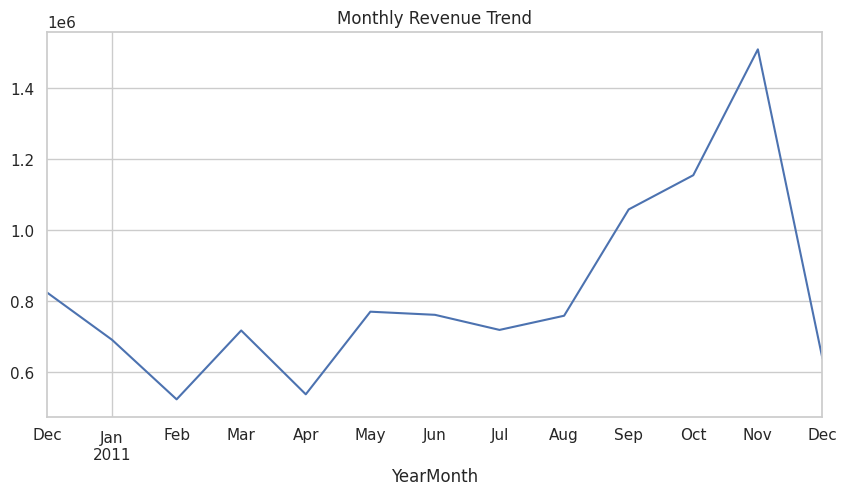

In [18]:
#Visualize monthly revenue trend
monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

In [19]:
#Customer Purchase Frequency
purchase_frequency = df_customers.groupby('CustomerID')['InvoiceNo'].nunique()

print("Average Purchase Frequency:", round(purchase_frequency.mean(), 2))

Average Purchase Frequency: 4.27


In [20]:
#Customer Distribution
purchase_frequency.describe()

,InvoiceNo
count,4338.000000
mean,4.272015
std,7.697998
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,209.000000


In [21]:
# Top 10 Products by Revenue
top_products = (
    df_full.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64


In [22]:
#Revenue by Country
country_revenue = (
    df_full.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(country_revenue.head(10))

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [23]:
#Top Customers by Revenue
top_customers = (
    df_customers.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


Product Analysis

In [24]:
non_products = [
    'POSTAGE',
    'DOTCOM POSTAGE',
    'Manual',
    'BANK CHARGES',
    'AMAZON FEE'
]
df_products = df_full[~df_full['Description'].isin(non_products)].copy()
df_products.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


Operational entries such as postage and manual charges were excluded from product performance analysis to ensure accurate identification of top-selling merchandise, while being retained in overall revenue KPIs to preserve financial integrity.

In [25]:
#Recalculate Top Product By Revenue
top_products_clean = (
    df_products.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_clean)

Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                          54117.76
Name: Revenue, dtype: float64


In [26]:
#Product Revenue Share
product_revenue = df_products['Revenue'].sum()
total_revenue = df_full['Revenue'].sum()

product_share = (product_revenue / total_revenue) * 100
print("Product Revenue Contribution %:", round(product_share, 2))

Product Revenue Contribution %: 96.47


This is the calculation of the revenue contribution from products excluding the non-product categories.

Rechecking all the three dataset

In [27]:
df_full.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [28]:
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [29]:
df_products.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [30]:
#Add time column to the "Customers Dataset"
df_customers['YearMonth'] = df_customers['InvoiceDate'].dt.to_period('M')
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


Export all the datasets

In [31]:
df_full.to_csv("retail_full.csv", index=False)
df_customers.to_csv("retail_customers.csv", index=False)
df_products.to_csv("retail_products.csv", index=False)